In [ ]:
# in this script want extract neural data from the HDF5 files
# Dataset for W. E. Allen, et al., "Thirst regulates motivated behavior through modulation of brainwide neural population dynamics", Science (2019)
# Data stacture:
'''
Each HDF5 file includes histological information, firing rate information, and behavioral information, as well as some basic information about each unit.

Histological:
areas (Nunit): area encodings using final collapsed hierarchy (area names listed in area_map.csv)
areas_aibs (Nunit): area encoding from Allen Brain Institute (AIBS) atlas.
areas_aibs_higher (Nunit): area encoding from Allen Brain Institute (AIBS) atlas at high-level cut of hierarchy.
depth (Nunit): depth of each unit along probe
locs (Nunit x 3): registered 3D location of each unit within the AIBS reference space.
Behavioral:
session (Ntrial): which session each trial come from (session 0 = endogenous thirst, session 1 = optogenetic stimulation, session 2 = washout)
behavior (5 x 600 x Ntrial): matrix of binary-encoded behavioral data, binned at 10 ms time resolution. 
Row 1: Go odor timing
Row 2: No-Go odor timing
Row 3: Reward time
Row 4: Lick times
Row 5: Stim times 
Activity:
rates (Nunit x 600 x Ntrial): firing rates for each unit binned at 10 ms time resolution (6 s per trial), by number of trials.
Diagnostic:
fp_rate (Nunit): estimated false positive rate (note: may be inaccurate)
avg_fr (Nunit): average firing rate of each neuron across session.'''

In [ ]:
import h5py
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import requests


In [ ]:
# helper function to get AIBS area name from structure ID 


# read online -> this is sp slow 

def get_aibs_name(struct_id):
    url = f"http://api.brain-map.org/api/v2/data/Structure/{struct_id}.json"
    r = requests.get(url).json()
    return r['msg'][0]['name']

# Download AIBS ontology CSV from Allen Brain API
ONTOLOGY_URL_JSON = "http://api.brain-map.org/api/v2/structure_graph_download/1.json"

def _traverse_structures(node, id_to_name, id_to_acronym=None):
    """Recursively collect id → name (and optionally acronym) from a nested AIBS structure node."""
    sid = int(node["id"])
    id_to_name[sid] = node["name"]
    if id_to_acronym is not None:
        id_to_acronym[sid] = node.get("acronym", "")

    for child in node.get("children", []):
        _traverse_structures(child, id_to_name, id_to_acronym)


def load_aibs_id_to_name(url: str = ONTOLOGY_URL_JSON, return_acronym: bool = False):
    """
    Download Allen Brain Institute ontology JSON and return:
      - id_to_name dict
      - (optionally) id_to_acronym dict
    """
    print(f"Downloading ontology from:\n  {url}")
    r = requests.get(url)
    r.raise_for_status()
    data = r.json()

    id_to_name = {}
    id_to_acronym = {} if return_acronym else None

    # data["msg"] is usually a list of root structures (often length 1)
    for root in data["msg"]:
        _traverse_structures(root, id_to_name, id_to_acronym)

    print(f"Collected {len(id_to_name)} structures from ontology.")
    if return_acronym:
        return id_to_name, id_to_acronym
    else:
        return id_to_name


def map_areas_to_names(areas_aibs: np.ndarray, id_to_name: dict) -> np.ndarray:
    """
    Map an array of AIBS area IDs (areas_aibs) to names.
    If an ID is missing, return 'UNKNOWN_<id>'.
    """
    names = []
    for a in areas_aibs:
        key = int(a)
        names.append(id_to_name.get(key, f"UNKNOWN_{key}"))
    return np.array(names, dtype=object)

In [4]:
data_dir = r'\\research.files.med.harvard.edu\neurobio\MICROSCOPE\Alireza\Datasets\Allen2019'
file_name = 'm0_mPFC_20170905_data.h5'
file_path = os.path.join(data_dir, file_name)
f = h5py.File(file_path, 'r')
# List all groups
print("Keys: %s" % f.keys())

Keys: <KeysViewHDF5 ['areas', 'areas_aibs', 'areas_aibs_higher', 'avg_fr', 'behavior', 'depth', 'fp_rate', 'locs', 'rates', 'session']>


  http://api.brain-map.org/api/v2/structure_graph_download/1.json
Collected 1327 structures from ontology.
          area_name        depth    avg_fr   fp_rate
0   Olfactory areas   732.444705  0.260105  0.000000
1    Prelimbic area  2231.164858  0.076671  0.000000
2    Prelimbic area  2804.217995  1.770031  0.043855
3  Infralimbic area  1674.322715  5.641509  0.107927
4   Olfactory areas   565.183225  0.304211  0.000000


c:\Users\Alireza\miniconda3\envs\basic_analysis\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


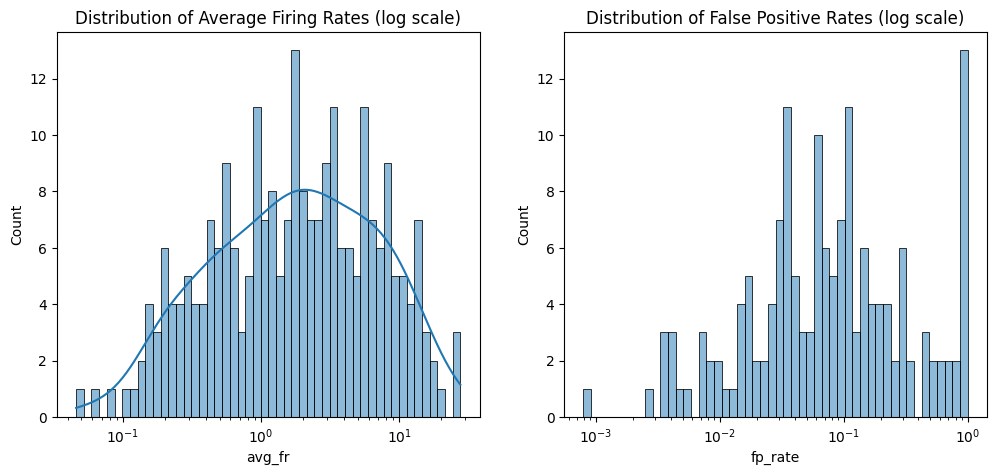

In [71]:
# let get all units info
id_to_name = load_aibs_id_to_name()
units_names = map_areas_to_names(areas_aibs, id_to_name)
units_depth = np.array(f['depth'])
units_fr = np.array(f['avg_fr'])
units_fp_rate = np.array(f['fp_rate'])

# let bild a dataframe of units info
units_df = pd.DataFrame({
    'area_name': units_names,
    'depth': units_depth,
    'avg_fr': units_fr,
    'fp_rate': units_fp_rate
})  
print(units_df.head())

# plot the distribution of average firing rates and fp_rate in log scale
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(units_df['avg_fr'], bins=50, kde=True, ax=ax[0], log_scale=(True, False))
ax[0].set_title('Distribution of Average Firing Rates (log scale)')
sns.histplot(units_df['fp_rate'], bins=50, kde=True, ax=ax[1], log_scale=(True, False))
ax[1].set_title('Distribution of False Positive Rates (log scale)')
plt.show()
areas_aibs = np.array(f['areas_aibs'])


In [ ]:
# let get neural data tensor 
neural_data = np.array(f['rates'])  # shape: (Nunits, 600, Ntrials)
# behavioral data tensor
behavior_data = np.array(f['behavior'])  # shape: (5, 600, Ntrials)
# get session info
session_info_id = np.array(f['session'])  # shape: (Ntrials,)
# which session each trial come from (session 0 = endogenous thirst, session 1 = optogenetic stimulation, session 2 = washout)
session_info_labels = {0: 'endogenous_thirst', 1: 'optogenetic_stimulation', 2: 'washout'}

# conver behavior data to a dataframe for easier handling
behavior_df = pd.DataFrame({
    'go_odor_time': list(behavior_data[0, :, :].T),
    'no_go_odor_time': list(behavior_data[1, :, :].T),
    'reward_time': list(behavior_data[2, :, :].T),
    'lick_time': list(behavior_data[3, :, :].T),
    'stim_time': list(behavior_data[4, :, :].T),
    'session_id': session_info_id,
    'session_info_labels': [session_info_labels[sid] for sid in session_info_id]
})
## let print numUnits and Ntrials
num_units, _, num_trials = neural_data.shape
print(f'Number of Units: {num_units}, Number of Trials: {num_trials}')
# let print number of trials per session
session_counts = pd.Series(session_info_id).value_counts().sort_index()
for session_id, count in session_counts.items():
    session_label = session_info_labels.get(session_id, f'unknown_{session_id}')
    print(f'Session {session_id} ({session_label}): {count} trials')


Number of Units: 250, Number of Trials: 314
Session 0.0 (endogenous_thirst): 314 trials


In [ ]:
# let add number of licks per trial
behavior_df['num_licks'] = behavior_df['lick_time'].apply(lambda x: np.sum(x))
behavior_df['go_or_nogo'] = behavior_df.apply(lambda row: 'go' if np.any(row['go_odor_time']) else ('no_go' if np.any(row['no_go_odor_time']) else 'none'), axis=1)

In [97]:
# Thirsty and sated blocks were determined using a Hidden Markov Model of the total number of licks per Go trial, smoothed with a 10 trial moving average filter.
# let fidn the Thirsty and sated blocks (there is one thirsty block falling one sated block in session 0) using Hidden Markov Model
from hmmlearn import hmm
def identify_thirsty_sated_blocks(behavior_df, lick_column='num_licks', go_nogo_column='go_or_nogo', smoothed_window=10, selected_session = 0, seed = 42):
    # Filter to only Go trials in the selected session
    session_trials = behavior_df[behavior_df['session_id'] == selected_session]
    go_trials = session_trials[session_trials[go_nogo_column] == 'go']
    
    # Smooth the lick counts with a moving average
    smoothed_licks = go_trials[lick_column].rolling(window=smoothed_window, center=True, min_periods=1).mean().values.reshape(-1, 1)
    
    # Fit HMM with 2 states (thirsty and sated)
    model = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=100, random_state=seed)
    model.fit(smoothed_licks)
    
    # Predict states
    hidden_states = model.predict(smoothed_licks)
    
    # Map states to 'thirsty' and 'sated' based on mean lick counts
    state_means = [np.mean(smoothed_licks[hidden_states == i]) for i in range(model.n_components)]
    thirsty_state = np.argmax(state_means)
    
    # Create a full series of states for all trials in the session
    full_states = np.full(len(session_trials), 'unknown', dtype=object)
    full_states[session_trials.index.isin(go_trials.index)] = ['thirsty' if state == thirsty_state else 'sated' for state in hidden_states]
    
    return full_states
behavior_df['thirsty_sated_state'] = identify_thirsty_sated_blocks(behavior_df)
# if the session is 0, and the signal is 'no_go', then the state is the sate of closest neighboring go trial (first next go trial then previous go trial)
def fill_no_go_states(behavior_df, state_column='thirsty_sated_state', go_nogo_column='go_or_nogo', session_column='session_id', selected_session=0):
    session_trials = behavior_df[behavior_df[session_column] == selected_session]
    for idx, row in session_trials.iterrows():
        if row[go_nogo_column] == 'no_go':
            # Find the closest Go trial
            go_trials = session_trials[session_trials[go_nogo_column] == 'go']
            if not go_trials.empty:
                # Get indices of Go trials
                go_indices = go_trials.index
                # Find the closest Go trial index
                closest_go_idx = go_indices[np.argmin(np.abs(go_indices - idx))]
                # Assign the state from the closest Go trial
                behavior_df.at[idx, state_column] = behavior_df.at[closest_go_idx, state_column]
    return behavior_df
behavior_df = fill_no_go_states(behavior_df)

In [100]:

behavior_df['thirsty_sated_state']

0      thirsty
1      thirsty
2      thirsty
3      thirsty
4      thirsty
        ...   
309      sated
310      sated
311      sated
312      sated
313      sated
Name: thirsty_sated_state, Length: 314, dtype: object

Number of licks in the first trial: 17


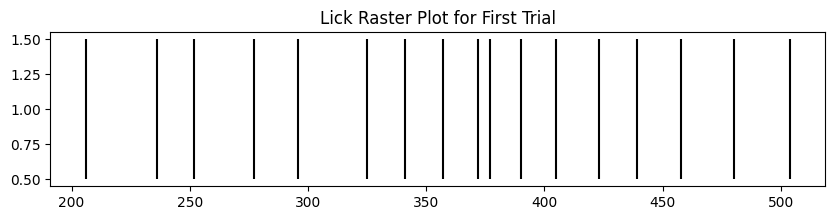

In [77]:
# lick raster for the first trial
first_trial_licks = behavior_df.iloc[10]['lick_time']
fig, ax = plt.subplots(figsize=(10, 2))
lick_indices = np.where(first_trial_licks == 1)[0]
ax.vlines(lick_indices, 0.5, 1.5, color='black')
ax.set_title('Lick Raster Plot for First Trial')
# let get number of this trial
num_on_licks = len(lick_indices)
print(f'Number of licks in the first trial: {num_on_licks}')

(314,)

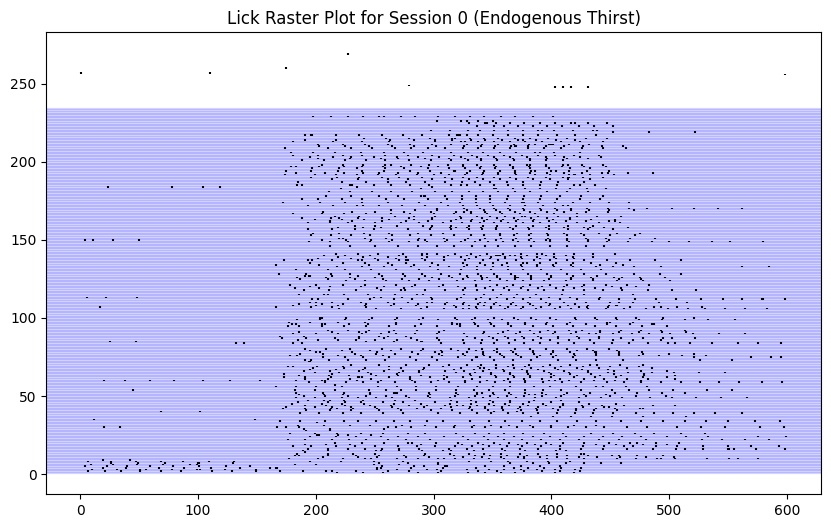

In [101]:
# let make lick raster plot for all trials in session 0
session_0_trials = behavior_df[behavior_df['session_id'] == 0]
fig, ax = plt.subplots(figsize=(10, 6))
for trial_idx, lick_times in enumerate(session_0_trials['lick_time']):
    lick_indices = np.where(lick_times == 1)[0]
    ax.vlines(lick_indices, trial_idx + 0.5, trial_idx + 1.5, color='black')
# shade thirsty and sated blocks
thirsty_indices = session_0_trials[session_0_trials['thirsty_sated_state'] == 'thirsty'].index
sated_indices = session_0_trials[session_0_trials['thirsty_sated_state'] == 'sated'].index
for idx in thirsty_indices:
    ax.axhspan(idx + 0.5, idx + 1.5, color='blue', alpha=0.1)
ax.set_title('Lick Raster Plot for Session 0 (Endogenous Thirst)')
session_info.shape
# 

In [57]:
session_info.shape

(314,)